# Описание данных

## Цель и задачи:

**Цель:** провести исследовательский анализ рынка заведений общественного питания Москвы.

**Задачи:** 
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - ответить на поставленные вопросы:  
        1) Какие категории заведений представлены в данных?  
        2) Какие административные районы Москвы присутствуют в данных?  
        3) Изучить соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения  
        4) Исследовать количество посадочных мест в заведениях  
        5) Исследовать рейтинг заведений  
        6) Изучить, с какими данными показывают самую сильную корреляцию рейтинги заведений?  
        7) Сгруппировать данные по названиям заведений и найти топ-15 популярных сетей в Москве  
        8) Изучите вариацию среднего чека заведения (столбец middle_avg_bill) в зависимости от района Москвы  
       
4. Сформулировать выводы по проведённому анализу.

## Данные

Данные состоят из двух датасетов:  
- `rest_info.csv` - информация о заведениях общественного питания
- `rest_price.csv` - информация о среднем чеке в заведениях общественного питания

### Описание датасета `rest_info.csv`

- `name` - название заведения;
- `address` - адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки): 0 — заведение не является сетевым; 1 — заведение является сетевым.
- `seats` — количество посадочных мест.

### Описание датасета `rest_price.csv`  

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:  
    «Средний счёт: 1000–1500 ₽»;  
    «Цена чашки капучино: 130–220 ₽»;  
    «Цена бокала пива: 400–600 ₽».  
    и так далее;  
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:  
    Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.  
    Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.  
    Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.  
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца   avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:  
    Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.  
    Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.  
    Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.



## 1. Загрузка данных и знакомство с ними  


Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.  

### 1.1 Загрузка данных


In [1]:
# Комментарий ревьюера 0
# Для задания по расчету корреляции требуется установить библиотеку
# Инсталлируем библиотеку phik
!pip install phik -U    
# Библиотека для расчета коэффициента корреляции phi_k
#from phik import phik_matrix

In [ ]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix


'\nКомментарий ревьюера 01\n\nВынужден закомментировать данную строчку кода:\n\n!pip install --upgrade pandas\n\nДело в том, что ты сначала импортируешь библиотеку с Сервера (первая строка кода в этой ячейке), \nа потом инсталлируешь ее до последней версии, но при этом подтягиваются другие библиотеки, \nкоторые необходиммы для pandas и из-за этого код далее падает.\n'

In [3]:
# Комментарий ревьюера 01
# Вот номер версии библиотеки на Сервере, посмотри у себя локально, она явно другая
print(pd.__version__)

1.2.4


In [4]:
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

### 1.2 - 1.3 Знакомство с данными и краткие выводы

In [5]:
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [6]:
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` состоит из 9 столбцов и 8406 строк.   
После первичного анализа можно сделать следующие выводы:  
* Большинство данных принадлежат к типу `object`. Размерность некоторых данных таких как `chain` можно оптимизировать  
* Пропуски содержатся в столбцах `hours` и `seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.  

Перейдем к датасету `rest_price.csv`

In [7]:
price_df.head(10)

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN
5,96ebceb1a09e4e3191133b9fe0379a64,средние,Средний счёт:199 ₽,199.0,NaN
6,0243288b78024af090b8e947842c969c,средние,Средний счёт:200–300 ₽,250.0,NaN
7,36aeb0ffa69c48fdb0021549520deb10,средние,Средний счёт:от 500 ₽,500.0,NaN
8,487167877eb04288bc90d4fa80646fc2,средние,Средний счёт:1000–1200 ₽,1100.0,NaN
9,ac32978af97641bfacf996e7f5a50ee5,средние,Цена бокала пива:250–350 ₽,NaN,NaN


In [8]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` состоит из 5 столбцов и 4058 строк.  
По аналогии с предыдущим датасетом можно отметить, что:   
   * Пропуски содержатся в столбцах `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`
   
Это говорит о том что данные не очень хорошего качества

### 1.5 Подготовка единого датафрейма  

In [9]:
df = info_df.merge(price_df, on='id', how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [10]:
# Комментарий ревьюера 0
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
# только не надо эту копию потом использовать в проекте
temp = df.copy() 
len(temp)

8406

## 2. Предобработка данных

### 2.1 Оптимизация типов данных



In [11]:
df['chain'] = df['chain'].astype('int8')
df['chain'].dtypes

dtype('int8')

Остальные поля можно оставить как есть т.к данные в них могут содержаться большие значения  

---

### 2.2 Проверка наличия пропусков в данных  

При первичном анализе мы обнаружили пропуски в столбце `hours` и `seats` датафрейма `info_df`. Узнаем абсолютное и относительное количество пропусков в этом столбце.

In [12]:
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [13]:
df.isna().sum()/df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

In [14]:
# Комментарий ревьюера 01
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    Параметры:   tmp0 (pd.DataFrame): Исходный DataFrame для анализа
    Возвращает:  Styler или строку: Объект Styler с подсветкой или сообщение об отсутствии пропусков
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean().round(4)
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    return missing_stats.style.background_gradient(cmap='coolwarm') if not missing_stats.empty else "Пропусков в данных нет"
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.063800
seats,3611,0.429600
price,5091,0.605600
avg_bill,4590,0.546000
middle_avg_bill,5257,0.625400
middle_coffee_cup,7871,0.936400


Количество пропусков в данных относительно общего кол-ва строк в столбцах `hours` ~ 6.4, `seats` ~ 43%, `price` ~ 60%, `avg_bill` ~ 54%,`middle_avg_bill` ~ 62% и `middle_coffee_cup` ~ 93%. В поле `hours` можно заменить пропуски на среднее значение. Для всех отсальных полей значение слишком большое и нужно искать причины.  

Возможные причины пропусков: 
Поле `hours`
 * Заведение закрылось, однако у нас нет данных о статусе заведений, поэтому достоверно проверить эту гипотезу не получится (MNAR)  
 * При обработке данных произошёл технический сбой. Технические ошибки могут привести к пропускам в данных, включая случаи, когда часы работы не были записаны (MCAR)
  
Поле `seats`  
* В заведние работает на вынос и в нем не предусмотрены посадочные места (MNAR) 
* При обработке данных произошёл технический сбой. Технические ошибки могут привести к пропускам в данных (MCAR)

Если сравнивать пропуски в объединенном датафрейме `df` и датафрейме `price_df` можно заметить, что число пропусков после объединения увеличилось, так как, используя левое соединение, мы тем самым создаем пустые поля в силу того, что размерности датафреймов сильно отличаются.

Причинами пропусков в `middle_avg_bill` и `middle_coffee_cup` могут быть: 

`middle_avg_bill`:  
* Заведение не относится к типу кафе или ресторана и в нем не подразвумевается прием пищи как основое действие, например: кофейня или бар. Проверить это можно проанализировав значения в столбце `category` в строках с пропусками (MAR). 

`middle_coffee_cup`:  
* Заведение не отностится к типу `кофейня`. Проверить это можно проанализировав значения в столбце `category` в строках с пропусками (MAR).   


Проверим догадку о пропусках в поле `seats`

In [15]:
df[df['seats'].isna()]['category'].value_counts()

кафе               1160
ресторан            773
кофейня             662
бар,паб             297
быстрое питание     254
пиццерия            206
столовая            151
булочная            108
Name: category, dtype: int64

Как видно, кафе и рестораны, составляют большую часть пропусков, поэтому гипотеза опровергнута

При дальнейшей работе с полем `seats` пустые значения могут интерпретироваться как 0 и влиять на показатели, поэтому стоит заменить пропуски на -1

In [16]:
df['seats'] = df['seats'].fillna(-1)

In [17]:
# Комментарий ревьюера 01
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.063800
price,5091,0.605600
avg_bill,4590,0.546000
middle_avg_bill,5257,0.625400
middle_coffee_cup,7871,0.936400


Далее проверим догадку о пропусках в `middle_avg_bill` и `middle_coffee_cup`

In [18]:
df['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [19]:
avg_bill_missing = df[df['middle_avg_bill'].isna()][['middle_avg_bill','category']]
avg_bill_missing['category'].value_counts()

кафе               1684
кофейня            1213
ресторан           1003
бар,паб             416
быстрое питание     366
пиццерия            238
булочная            203
столовая            134
Name: category, dtype: int64

Можно заметить что заведения типа `кофейня` содержат большое число пропусков, что подтверждает нашу гипотезу только отчасти потому что пропуски преимущественно содержаться в заведениях  `кафе`

In [20]:
coffee_cup_missing = df[df['middle_coffee_cup'].isna()][['middle_coffee_cup', 'category']]
coffee_cup_missing['category'].value_counts()

кафе               2374
ресторан           2043
кофейня             892
бар,паб             759
пиццерия            630
быстрое питание     602
столовая            315
булочная            256
Name: category, dtype: int64

`Кафе` и `ресторан` содержат преобладающее число пропусков, что подтверждает нашу гипотезу

---

### 2.3 Явные и неявные дубликаты в данных
Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [21]:
df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id` клиентов должны быть уникальными, то есть каждая строка в данных — уникальный клиент:

In [22]:
df.duplicated(subset='id').sum()

0

Теперь проверим корректность написания категориальных значений в данных `info_df`.

In [23]:
for column in ['district', 'category']:
    print(f'Уникальные значения в столбце {column}')
    print(info_df[column].sort_values().unique())
    print()

Уникальные значения в столбце district
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце category
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']



В обозначении района и  категории заведения нет ошибок.  

---

Также проверим неявные дубликаты в столбцах `name` и `address`

In [24]:
df['name'] = df['name'].str.lower().str.strip()
df['address'] = df['address'].str.lower().str.strip()

duplicates = df.duplicated(subset=['name', 'address'], keep=False).sum()
print (duplicates)

8


Найдено 8 дубликатов

In [25]:
df = df.drop_duplicates(subset=['name', 'address'])
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float64
 7   chain              8402 non-null   int8   
 8   seats              8402 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int8(1), object(8)
memory usage: 861.5+ KB
None


### 2.4 создание столбца is_24_7

In [26]:
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'
df['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [27]:
# Комментарий ревьюера 01
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


### 2.5 Промежуточные выводы после предобработки  

В результате предобработки данных были выполнены следующие действия:
Изучены пропуски в данных. Пропуски обнаружились в столбцах `hours` ~ 6.4% , `seats` ~ 43%, `price` ~ 60%, `avg_bill` ~ 54%,`middle_avg_bill` ~ 62% и `middle_coffee_cup` ~ 93%. Пропуски в столбце `seats` были заменены на -1. Остальные пропуски могут отражать особенности и специфику заведений и не являться ошибкой в данных. Поэтому их оставили как есть.  
При проверке данных на явные и неявные дубликаты было обнаружено и удалено 8 неявных дубликатов в полях `name` и `address`. 

## 3. Исследовательский анализ данных
Исследовательский анализ исходных данных и ответы на вопросы


### 3.1 Категория заведений
**Задача:** Исследовать количество объектов общественного питания по каждой категории

Распределение данных по уникальным значениям столбца `category`

In [28]:
df['category'].value_counts()

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [29]:
df['category'].value_counts()/df.shape[0]

кафе               0.282790
ресторан           0.243037
кофейня            0.168174
бар,паб            0.090931
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: category, dtype: float64

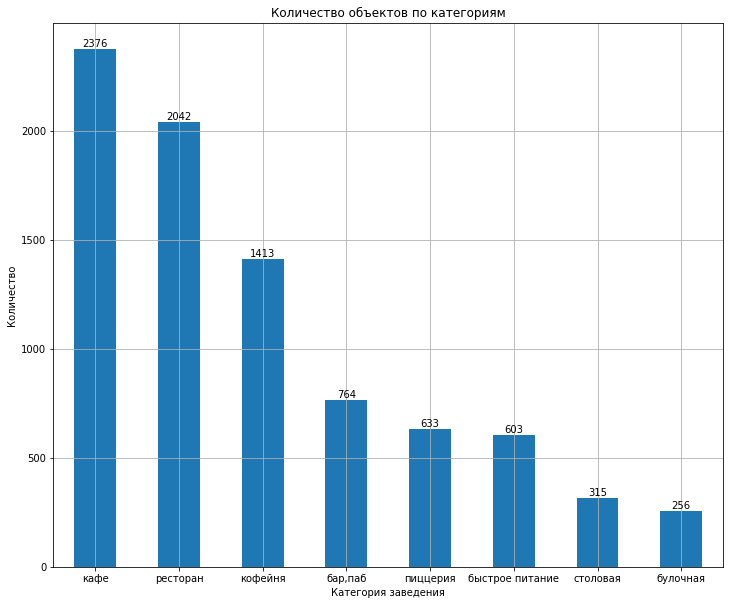

In [30]:
plt.figure(figsize=(12,10))

values = df['category'].value_counts()
ax = values.plot(kind='bar', rot=0, legend=False)

for i, v in enumerate(values):
    plt.text(i, v + 10, str(v), ha='center')

plt.title('Количество объектов по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Количество')
plt.grid()
plt.show()

`кафе`, `ресторан`, `кофейня` - 3 наиболее частовстерчающиеся категории, в то время как `столовая ` и `булочная` - наименее популярные

### 3.2 Административные районы Москвы

**Задача:** Исследовать административные районы Москвы присутствуют в данных? Исследовать распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

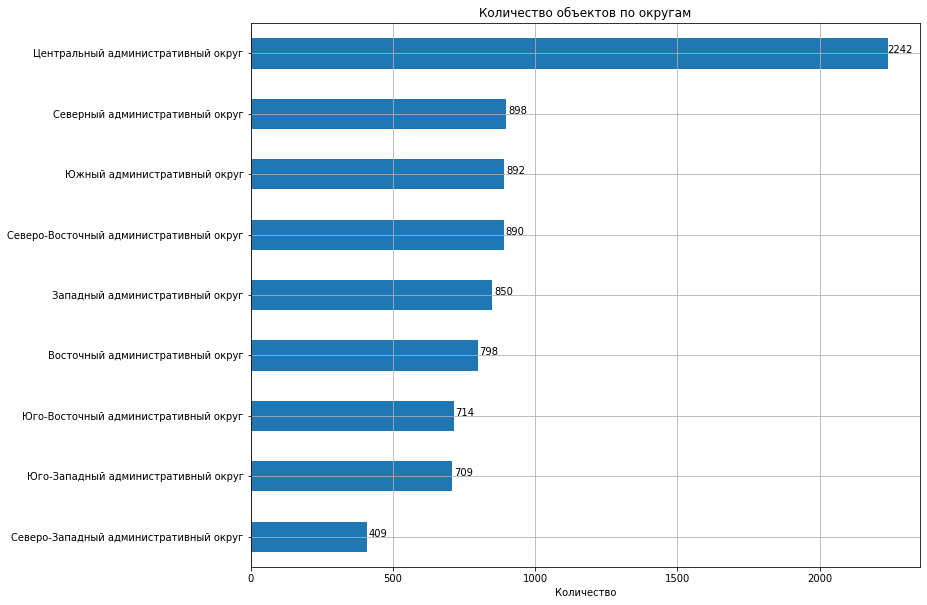

In [31]:
plt.figure(figsize=(12,10))

values = df['district'].value_counts().iloc[::-1]
ax = values.plot(kind='barh', rot=0, legend=False)

for i, v in enumerate(values):
    plt.text(v+40, i, str(v), ha='center')

#ax = df['district'].value_counts().iloc[::-1].plot(kind='barh', rot=0, legend=False)
#ax.bar_label(ax.containers[0], fmt='%d')

plt.title('Количество объектов по округам')
plt.xlabel('Количество')

plt.grid()
plt.show()

В данных представлены следующие административные округи Москвы: ЦАО, САО, ВАО, ЮАО, ЗАО,
СВАО, ЮЗАО, ЮВАО, СЗАО. Самое большое количество заведений в ЦАО - 2242 заведений. В
остальных районах в несколько раз меньше заведений:
в САО - 898 заведение,
в ЮАО - 892 заведений,
в СВАО - 890 заведения,
в ЗАО - 850 заведения.  

Наименьшее число заведений в СЗАО - 409

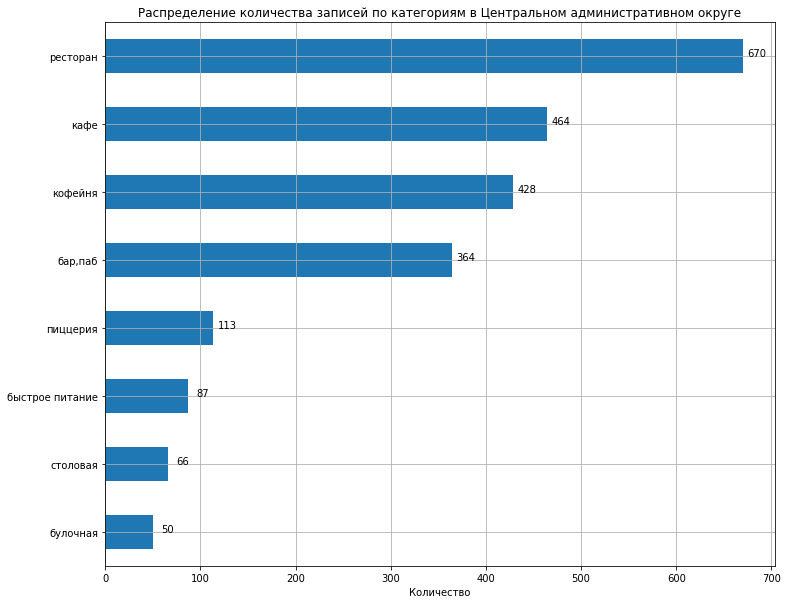

In [32]:
plt.figure(figsize=(12,10))

#ax = df[df['district']=='Центральный административный округ']['category'].value_counts().iloc[::-1].plot(kind='barh', rot=0, legend=False)
#ax.bar_label(ax.containers[0], fmt='%d')

values = df[df['district']=='Центральный административный округ']['category'].value_counts().iloc[::-1]
ax = values.plot(kind='barh', rot=0, legend=False)

for i, v in enumerate(values):
    plt.text(v+15, i, str(v), ha='center')

plt.title('Распределение количества записей по категориям в Центральном административном округе')
plt.xlabel('Количество')

plt.grid()
plt.show()

Анализируя распределение количества записей по категориям, видно, что самыми
расспространенными категориями являются - ресторан, кафе и кофейня

### 3.3 Cоотношение сетевых и несетевых заведений  

**Задача:** изучить соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми?

0    0.618781
1    0.381219
Name: chain, dtype: float64


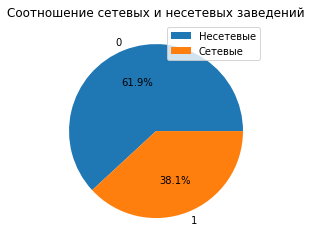

In [33]:
print(df['chain'].value_counts(normalize=True))

ax = df['chain'].value_counts(normalize=True).plot(kind='pie', legend=True, autopct='%1.1f%%')
ax.legend(['Несетевые', 'Сетевые'])

plt.title('Cоотношение сетевых и несетевых заведений')
plt.ylabel('')
plt.show()

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Правильное решение.</font>

Несетевых заведений на 23.8% меньше

бар,паб            21.99
столовая           27.94
кафе               32.79
ресторан           35.70
быстрое питание    38.47
кофейня            50.96
пиццерия           52.13
булочная           61.33
Name: category, dtype: float64


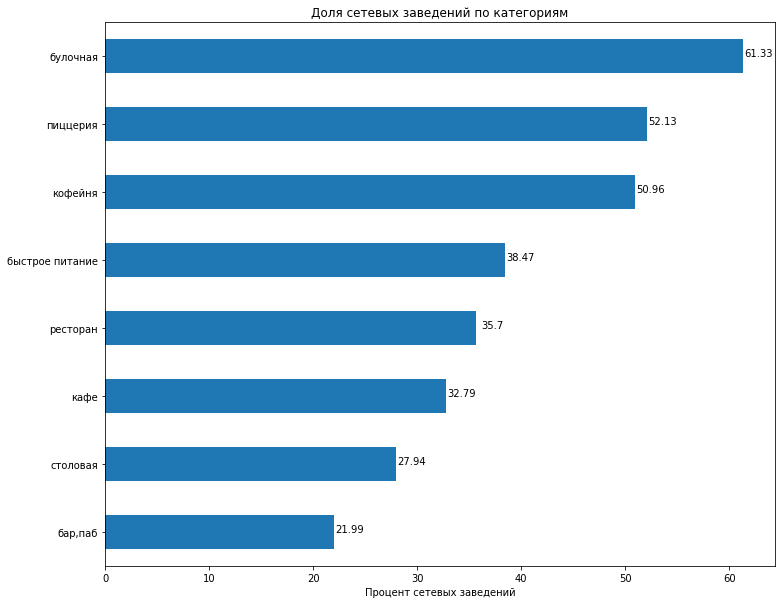

In [34]:
total_count = df['category'].value_counts()
chain_count = df[df['chain']==1]['category'].value_counts()
chain_share = round(chain_count/ total_count, 4) * 100
chain_share = chain_share.sort_values(ascending=True)
print(chain_share)


plt.figure(figsize=(12,10))

#ax = chain_share.plot(kind='barh', legend=False, rot=0)
#ax.bar_label(ax.containers[0], fmt='%.2f')

values = chain_share
ax = values.plot(kind='barh', rot=0, legend=False)

for i, v in enumerate(values):
    plt.text(v+1.5, i, str(round(v,2)), ha='center')

plt.xlabel('Процент сетевых заведений')
plt.title('Доля сетевых заведений по категориям')
plt.show()

Сетевых заведений: 38.1%  
Несетевых заведений: 61.9%  

По графику "Доля сетевых заведений по категориям" видно, что сетевыми явлются чаще всего - булочные,
пиццерии и кофейни

### 3.4 Количество посадочных мест  

**Задача:** Исследоавть количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Привести для каждой категории заведений наиболее типичное для него количество посадочных мест

In [35]:
filtered_seats = df[df['seats'] != -1]
filtered_seats['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

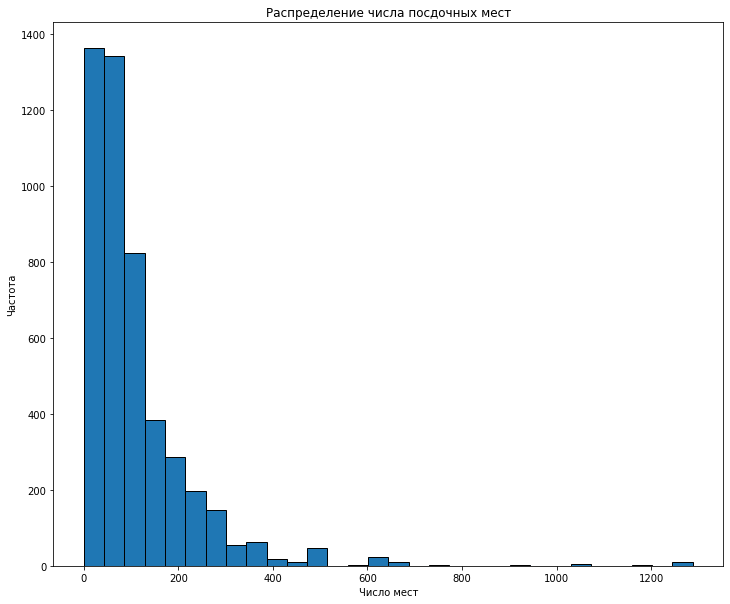

In [36]:
plt.figure(figsize=(12,10))
ax = filtered_seats['seats'].plot(kind='hist', bins=30, edgecolor='black', rot=0)

plt.title('Распределение числа посдочных мест')
plt.xlabel('Число мест')
plt.ylabel('Частота')
plt.show()


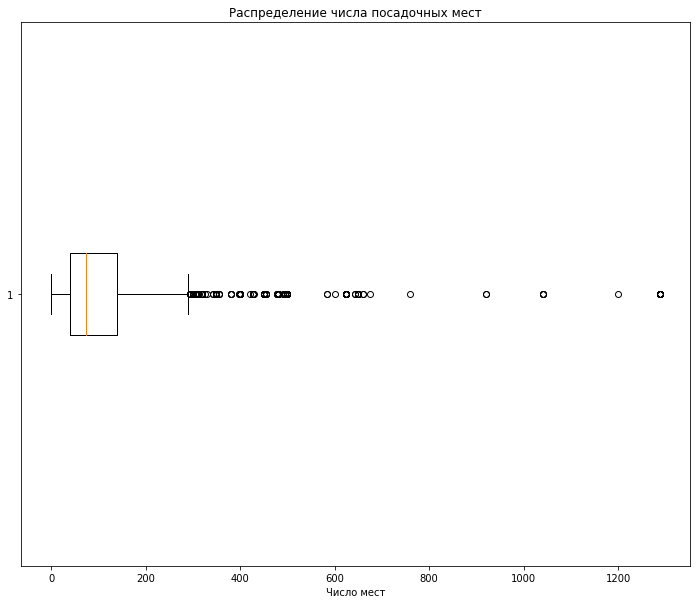

In [37]:
plt.figure(figsize=(12,10))
plt.boxplot(filtered_seats['seats'], vert=False)
plt.title("Распределение числа посадочных мест")
plt.xlabel('Число мест')
plt.show()

Как видно из графиков, данные содержат очень много выбросов. Как видно из графика значения > 300 можно считать выбросами.  
Узнаем их количество

In [38]:
seats_outliers = (filtered_seats['seats'] > 300).value_counts()
seats_outliers = seats_outliers.sort_index(ascending = False)
print(seats_outliers)

True      251
False    4541
Name: seats, dtype: int64


251 значение - выбросы  

Уберем выбросы и снова посмотрим на диаграмму размаха

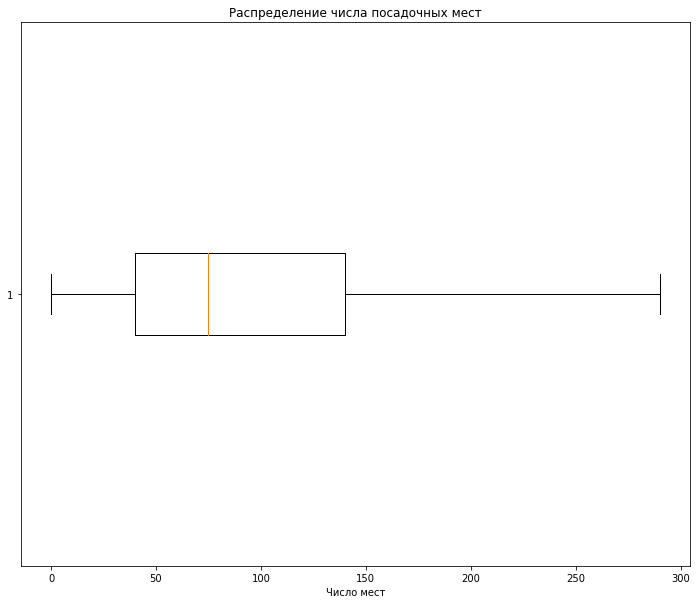

In [39]:
plt.figure(figsize=(12,10))
plt.boxplot(filtered_seats['seats'], vert=False, showfliers=False)
plt.title("Распределение числа посадочных мест")
plt.xlabel('Число мест')
plt.show()

Видно, что в основном данные распределеныв промежутке от 40 до 140 посадочных мест.

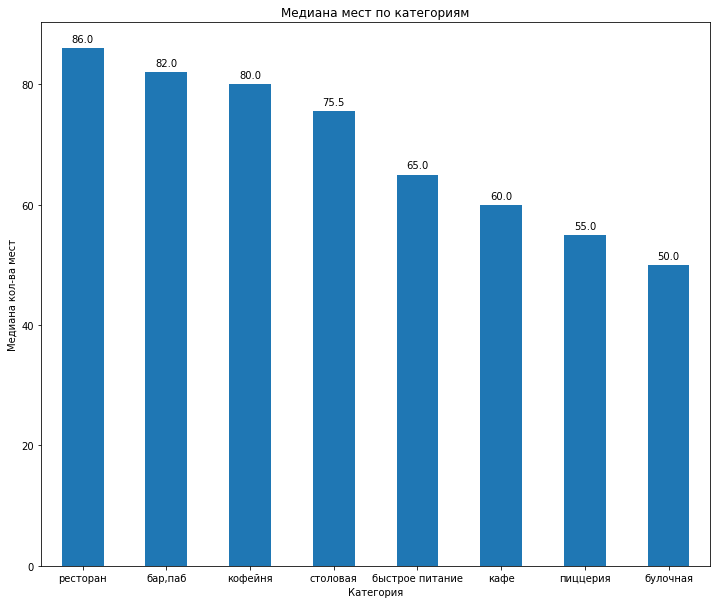

In [40]:
#filtred_seats = filtered_seats[filtered_seats['seats'] < 300]

count_seats = filtered_seats.groupby('category')['seats'].median()
count_seats = count_seats.sort_values(ascending=False)

plt.figure(figsize=(12,10))

#ax = count_seats.plot(kind='bar', legend=False, rot=0)
#ax.bar_label(ax.containers[0], fmt='%.2f')

values = count_seats
ax = values.plot(kind='bar', rot=0, legend=False)

for i, v in enumerate(values):
    plt.text(i, v+1, str(v), ha='center')

plt.title('Медиана мест по категориям')
plt.xlabel('Категория')
plt.ylabel('Медиана кол-ва мест')
plt.show()

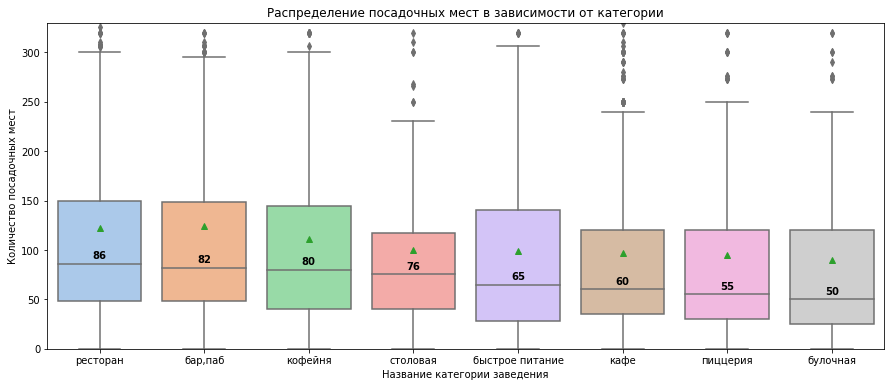

In [61]:
# Комментарий ревьюер 2
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

tmp = filtered_seats.copy()  # Создаем копию датасета, чтобы не работать с исходным

# Создаем список категорий сортированный по медианам
order = tmp.groupby('category')['seats'].median().sort_values(ascending=False).index 

# Рассчитываем медианы для каждой категории
medians = tmp.groupby('category')['seats'].median().sort_values(ascending=False)

# Построение диаграммы размаха с использованием seaborn
plt.figure(figsize=(15, 6))
ax = sns.boxplot(x='category', 
                y='seats', 
                data=tmp, 
                showmeans=True,  # Зеленые треугольники показывают среднее значение
                order=order,
                palette='pastel').set(title='Распределение посадочных мест в зависимости от категории', 
                             xlabel='Название категории заведения', 
                             ylabel='Количество посадочных мест',
                             ylim=(0, 330))

# Добавляем подписи медиан
for i, category in enumerate(order):
    median_val = medians[category]
    # Добавляем текст на позицию (x=i, y=median_val+5) для лучшей читаемости
    plt.text(i, median_val + 5, f'{median_val:.0f}', 
             horizontalalignment='center', 
             fontsize=10,
             color='black',
             weight='semibold')

# Отображение диаграммы
plt.show()

В тройке лидеров по медианному числу мест в заведении - `ресторан`, `бар,паб` и `кофейня`  

В основном количество посадочных мест варьируется от 40 до 140 мест, но также присутствуют и выбросы

**Возможные причины выбросов:**  
* Крупные рестораны, рассчитанные на массовые мероприятия (банкеты, свадьбы).  
* Столовые и фуд-корты в торговых центрах, где у одного объекта может быть несколько сотен посадочных мест.  
* Заведения на вокзалах, в аэропортах, кампусах 
  
* Часть выбросов может быть результатом некорректного ввода: например, вместо 120 мест указали 1200. 

* Рестораны при отелях, концертных залах или спортивных аренах.  

### 3.5 Рейтинг заведений  

**Задача:** исследовать рейтинг заведений. Визуализировать распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [41]:
df.groupby('category')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387696,0.380392,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268359,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124285,0.566001,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290402,0.413143,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0


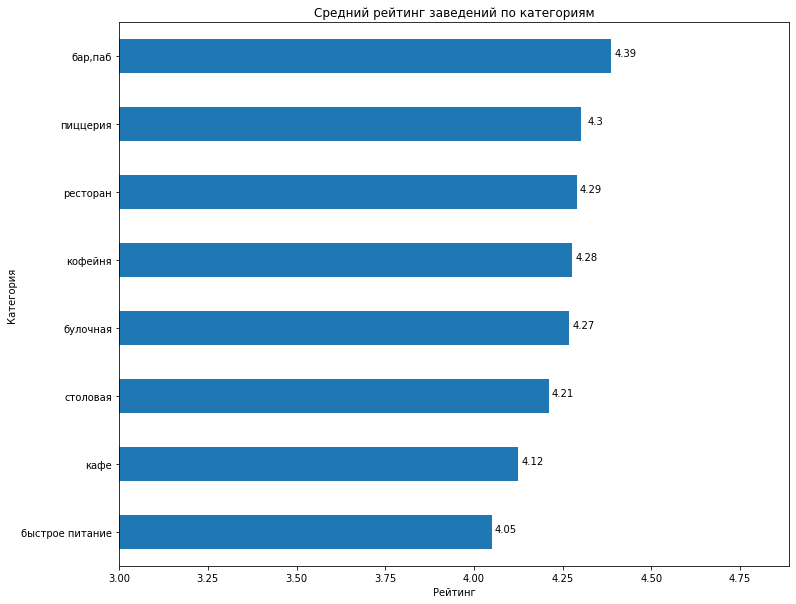

In [42]:
plt.figure(figsize=(12, 10))

rating = df.groupby('category')['rating'].mean()
rating = rating.sort_values(ascending=True)

#ax = rating.plot(kind='barh', legend=False, rot=0)
#ax.bar_label(ax.containers[0], fmt='%.2f')

values = rating
ax = values.plot(kind='barh', rot=0, legend=False)

for i, v in enumerate(values):
    plt.text(v+0.04, i, str(round(v,2)), ha='center')

plt.xlim(3, rating.max() + 0.5)

plt.title('Средний рейтинг заведений по категориям')
plt.xlabel('Рейтинг')
plt.ylabel('Категория')

plt.show()

Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [43]:
rating.describe()

count    8.000000
mean     4.238871
std      0.107241
min      4.050249
25%      4.189643
50%      4.272821
75%      4.293117
max      4.387696
Name: rating, dtype: float64

Стандартное отклонение = 0.107, значит все значения близки друг к другу  
Медиана очень близка к среднему, значит распределение значений симметричное.

### 3.6 Корреляция рейтига и других данных  

**Задача:** изучить, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построить и визуализировать матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выбрать самую сильную связь и проверить её.

In [44]:
#Создание копии датасета
df_copy = df.copy()

df_copy['seats'] = df_copy['seats'].replace(-1, pd.NA)

In [45]:
#df_copy = df[['district', 'category', 'chain', 'seats', 'price', 'is_24_7', 'rating']].copy()
#df_copy['is_24_7'] = df_copy['is_24_7'].astype(int)

correlation_matrix = df_copy[['district', 'category', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix()
correlation_matrix.loc[correlation_matrix.index != 'rating', ['rating']].sort_values(by='rating', ascending=False)


interval columns not set, guessing: ['chain', 'rating']


/opt/conda/lib/python3.9/site-packages/pandas/core/missing.py:56: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= arr == x


,rating
price,0.220295
district,0.200761
category,0.189716
seats,0.152723
is_24_7,0.150365
chain,0.107833


In [46]:
# Комментарий ревьюера
df['seats'].value_counts().head(2)

-1.0     3610
 40.0     253
Name: seats, dtype: int64

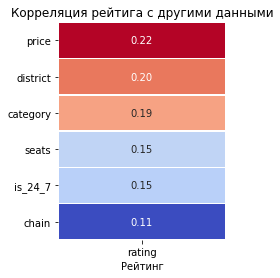

In [47]:
plt.figure(figsize=(3,4))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=False)

plt.title('Корреляция рейтига c другими данными')
plt.xlabel('Рейтинг')

plt.show()

Наибольшая связь `rating` наблюдается с `price`

In [48]:
df_copy.groupby('price')['rating'].mean()

price
высокие          4.436611
выше среднего    4.386348
низкие           4.173077
средние          4.297874
Name: rating, dtype: float64

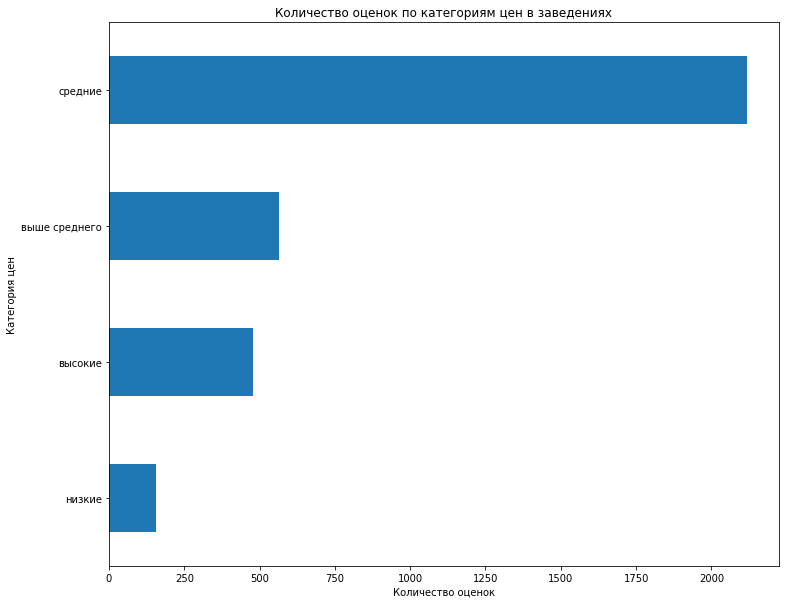

Количество оценок по категориям цен в заведениях


,price,rating
3,средние,2117
1,выше среднего,564
0,высокие,478
2,низкие,156


In [49]:
df_rating_price = df_copy.groupby('price')['rating'].agg('count').reset_index()
df_rating_price.sort_values(by='rating', ascending=True).plot(kind='barh', x='price', y='rating', legend=False, figsize=(12,10))

plt.title('Количество оценок по категориям цен в заведениях')
plt.ylabel('Категория цен')
plt.xlabel('Количество оценок')
plt.show()

print('Количество оценок по категориям цен в заведениях')
df_rating_price.sort_values(by='rating', ascending=False)

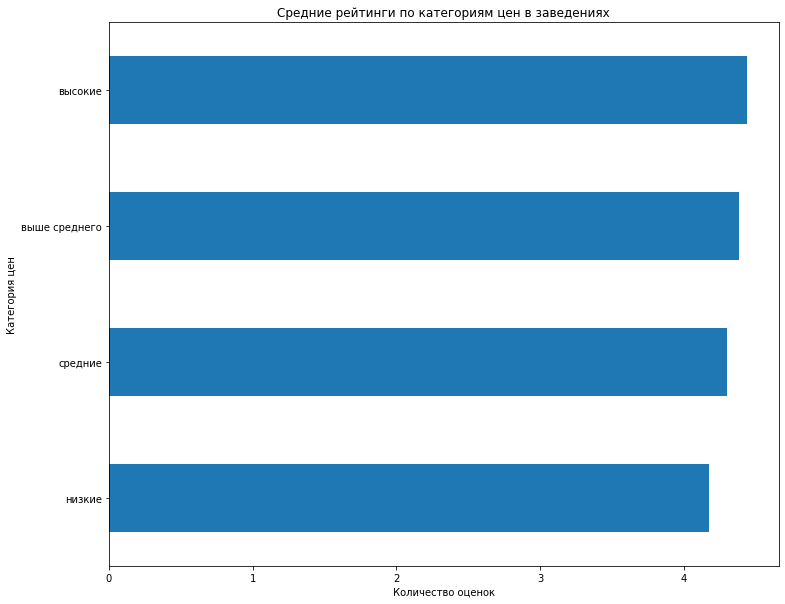

Cредние рейтинги по категориям цен в заведениях


,price,rating
0,высокие,4.436611
1,выше среднего,4.386348
3,средние,4.297874
2,низкие,4.173077


In [50]:
df_rating_price = df_copy.groupby('price')['rating'].agg('mean').reset_index()
df_rating_price.sort_values(by='rating', ascending=True).plot(kind='barh', x='price', y='rating', legend=False, figsize=(12,10))
plt.title('Cредние рейтинги по категориям цен в заведениях')
plt.ylabel('Категория цен')
plt.xlabel('Количество оценок')
plt.show()
print('Cредние рейтинги по категориям цен в заведениях')
df_rating_price.sort_values(by='rating', ascending=False)

Больше всего оценок рейтинга у заведений в `среднем` ценвом диапазоне (2117
оценок), затем идут категории цен "выше среднего" и "высокие" - 564 и 478 оценок соответственно.
Из этого можно сделать вывод что посетители чаще ходят в заведения со средней оценкой.
Самый высокий средние рейтинг у заведений в `высоком` ценовом диапазоне - 4.44, у заведений с ценами
`выше среднего` - 4.39, `средними` ценами - 4.3, заведения с `низкими` ценами имеют самый низкий
рейтинг - 4.17. Вероятно это связано с уровнем обслуживания в заведениях.

### 3.7 Топ 15 популярных сетей в Москве  

**Задача:** Сгруппировать данные по названиям заведений и найти топ-15 популярных сетей в Москве. Для них посчитать значения среднего рейтинга. Определить к какой категории заведений они относятся 

In [51]:
df_chain = df[df['chain'] == 1]

top_15 = (df_chain.groupby(['name','category']).agg(
    count=('name', 'count'),
    avg_rating=('rating', 'mean')
).sort_values('count', ascending=False).head(15).reset_index())

print(top_15)

                                   name  category  count  avg_rating
0                           шоколадница   кофейня    119    4.178151
1                        домино'с пицца  пиццерия     76    4.169737
2                            додо пицца  пиццерия     74    4.286486
3                      one price coffee   кофейня     71    4.064789
4                          яндекс лавка  ресторан     69    3.872464
5                                 cofix   кофейня     65    4.075385
6                                 prime  ресторан     49    4.114286
7                              кофепорт   кофейня     42    4.147619
8   кулинарная лавка братьев караваевых      кафе     39    4.394872
9                               теремок  ресторан     36    4.105556
10                             cofefest   кофейня     31    3.977419
11                              чайхана      кафе     26    3.946154
12                              буханка  булочная     25    4.416000
13                           drive

In [52]:
top_15['category'].value_counts()

кофейня     6
ресторан    3
кафе        3
пиццерия    2
булочная    1
Name: category, dtype: int64

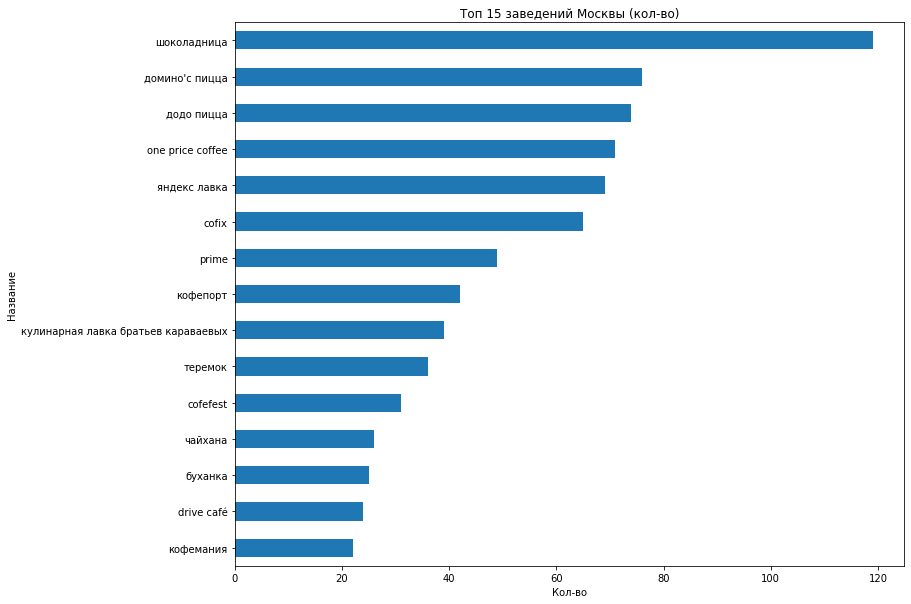

In [53]:
top_15.sort_values('count', ascending=True).plot(kind='barh', x='name', y='count', legend=False, figsize=(12,10))

plt.title('Топ 15 заведений Москвы (кол-во)')
plt.ylabel('Название')
plt.xlabel('Кол-во')

plt.show()

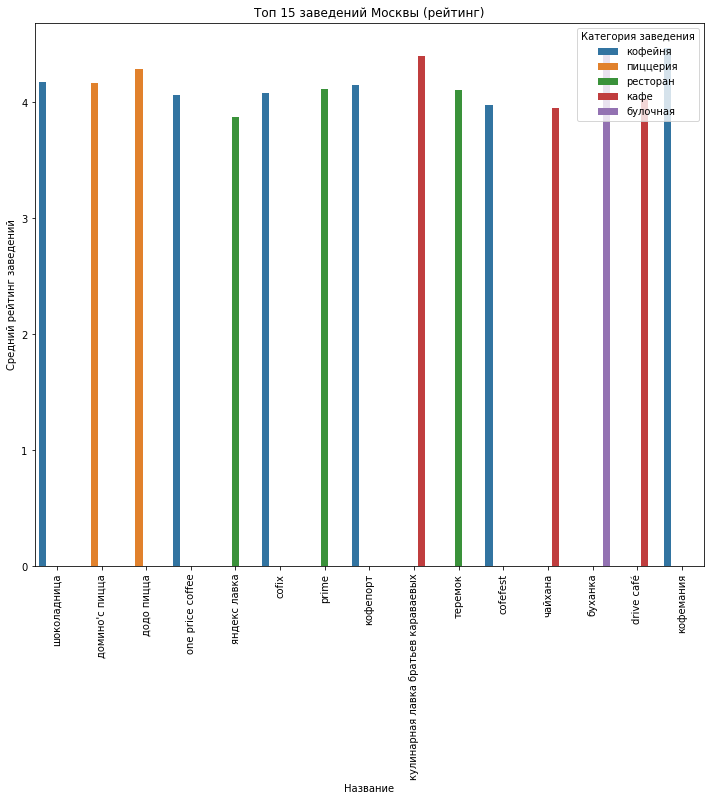

In [54]:
plt.figure(figsize=(12,10))
sns.barplot(data=top_15,x='name',y='avg_rating',hue='category')

plt.title('Топ 15 заведений Москвы (рейтинг)')
plt.legend(title='Категория заведения')
plt.xlabel('Название')
plt.ylabel('Средний рейтинг заведений')
plt.xticks(rotation=90)

plt.show()

Самые популярные сети: Шоколадница, Домино'c Пицца, Додо Пицца, One Price Coffee.  
Среди 15 популярных сетей 6 кофеен, 3 ресторана, 3 кафе, 2 пиццерии и 1 булочная.  
Самый высокий рейтинг у Кофемании - 4.46.  
Самый низкий рейтинг у Яндекс Лавки - 3.87

### Вариация среднего чека заведения  

**Задача**: изучить вариацию среднего чека заведения в зависимости от района Москвы. Проанализировать цены в центральном административном округе и других. Определить как удалённость от центра влияет на цены в заведениях

In [55]:
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

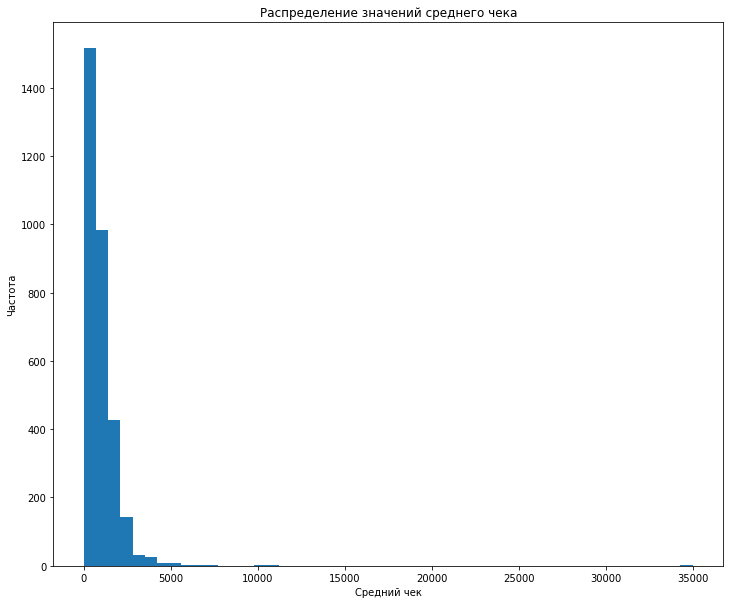

In [56]:
plt.figure(figsize=(12,10))
df['middle_avg_bill'].plot(kind='hist', bins=50)

plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')
plt.show()

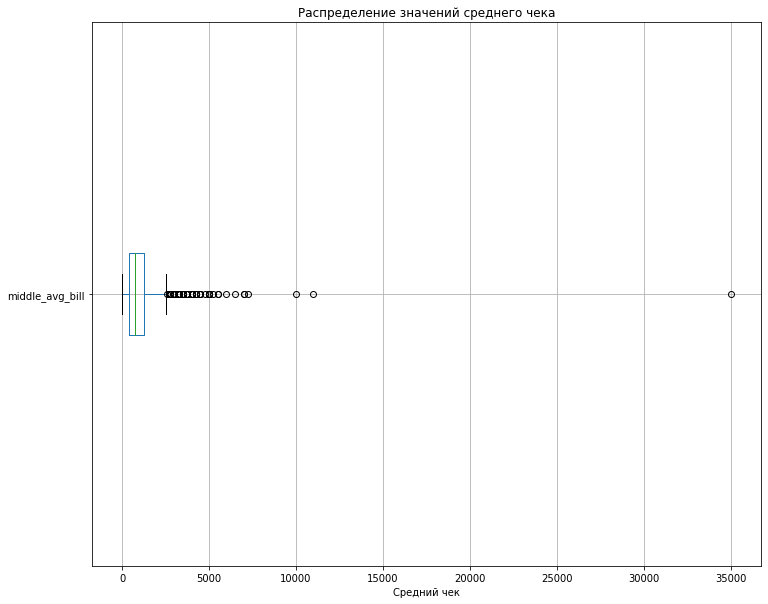

In [57]:
plt.figure(figsize=(12,10))

df.boxplot(column='middle_avg_bill', vert=False)

plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')

plt.show()

Средний чек имеет сильное смещение влево

In [58]:
result = (df.groupby('district')['middle_avg_bill']
            .agg(median='median', mean='mean')
            .reset_index())

print(result)

                                  district  median         mean
0         Восточный административный округ   575.0   820.626923
1          Западный административный округ  1000.0  1053.225490
2          Северный административный округ   650.0   927.959627
3  Северо-Восточный административный округ   500.0   716.611296
4   Северо-Западный административный округ   700.0   822.222930
5       Центральный административный округ  1000.0  1191.057547
6     Юго-Восточный административный округ   450.0   654.097938
7      Юго-Западный административный округ   600.0   792.561702
8             Южный административный округ   500.0   834.398089


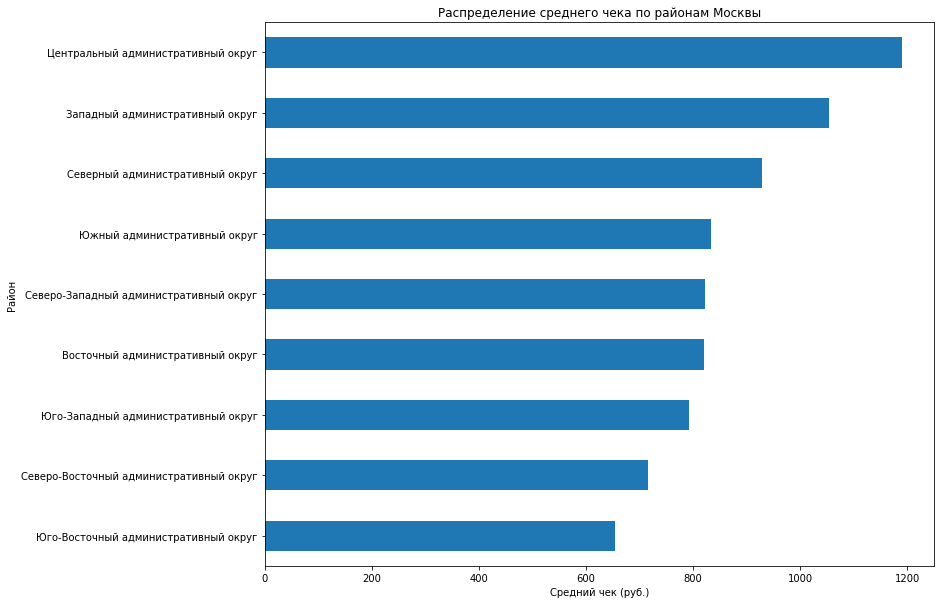

In [59]:
plt.figure(figsize=(12,10))

df['middle_avg_bill'].describe()

avg_bills = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=True)

avg_bills.plot(kind='barh', legend=False)
plt.title('Распределение среднего чека по районам Москвы')
plt.xlabel('Cредний чек (руб.)')
plt.ylabel('Район')

plt.show()

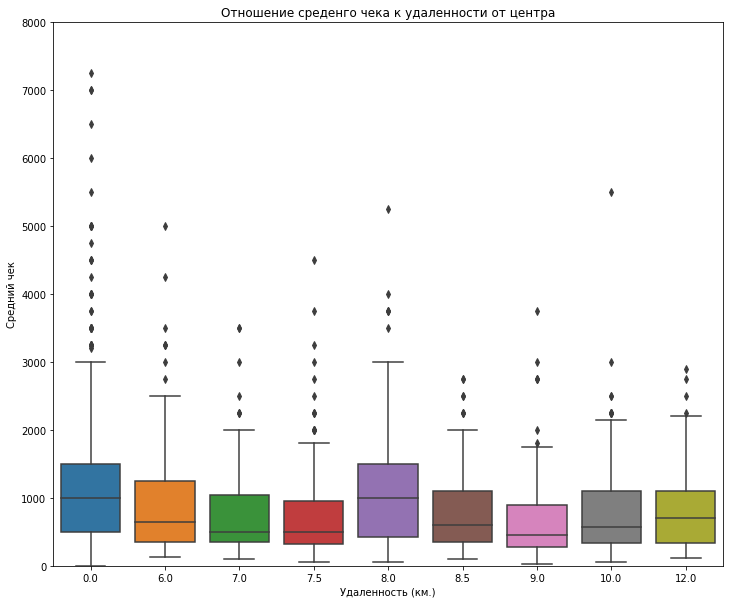

In [60]:
dist = {
    'Центральный административный округ': 0.0,
    'Северный административный округ': 6.0,
    'Южный административный округ': 7.0,
    'Северо-Восточный административный округ': 7.5,
    'Западный административный округ': 8.0,
    'Юго-Западный административный округ': 8.5,
    'Юго-Восточный административный округ': 9.0,
    'Восточный административный округ': 10.0,
    'Северо-Западный административный округ': 12.0,
}

df['dist_km'] = df['district'].map(dist)
plt.figure(figsize=(12,10))
plt.ylim(0, 8000)

sns.boxplot(x=df['dist_km'], y=df['middle_avg_bill'])
plt.title('Отношение среденго чека к удаленности от центра')
plt.xlabel('Удаленность (км.)')
plt.ylabel('Средний чек')
plt.show()

Самый высокий средний чек также в ЦАО (1191 рублей), самый низкий в ЮВАО (654 рублей).
В центре средний чек заметно выше, чем в большинстве удалённых районов:  
медиана около 1000, а в удалённых районах часто ниже ~700–800;  
много «высоких» значений, включая чеки выше 5000–7000.    
На удалённости 8 км встречаются чеки, сопоставимые с центром (возможно, элитные рестораны в спальных районах или загородные места).

### Промежуточный вывод  

Самые распространенные категории заведений: ресторан, кафе и кофейня;  
В данных представлены следующие административные округи Москвы: ЦАО, САО, ВАО, ЮАО, ЗАО, СВАО, ЮЗАО, ЮВАО, СЗАО. Самое большое количество заведений в ЦАО - 2242 заведений. В остальных районах в несколько раз меньше заведений;    
Несетевых заведений на 23,8% больше, чем сетевых;  
Наблюдается интерес к кофейням с большим числом посадочных мест, однако наибольшей вместимостью всё же отличаются рестораны и бары/пабы;  
Средний рейтинг во всех категориях заведений превышает отметку 4: самые высокие оценки у баров и пабов (4.39), а самые низкие — у заведений быстрого питания (4.05);  
Корреляционный анализ показал, что рейтинг слабо связан с другими показателями (все значения корреляции ниже 0.3). Наибольшая зависимость наблюдается от округа (0.2), но разброс между районами при этом несущественный;  
Среди сетевых заведений лидируют «Шоколадница», «Додо Пицца» и «Домино’с Пицца». Наибольшее количество сетевых объектов приходится на кофейни и рестораны;  
Больше всего данных о среднем чеке собрано по Центральному административному округу. При этом удалённость от центра влияет на его величину: разница между районами превышает 500 рублей в среднем;  

## Итоговый вывод

**Цели и задачи**. В рамках проекта изучили и очистили объединённый датасет из двух таблиц: `rest_info`(характеристики заведений) и `rest_price` (ценовые показатели). Основная цель — понять структуру рынка общественного питания Москвы: распределение заведений по категориям, округам и сетям; вместимость залов; оценить рейтинги, цены и их взаимосвязи; выявить популярные бренды и проверить, как средний чек зависит от расстояния от центра.  

**Предобработка и анализ данных**. После загрузки данные проверили на дубликаты и пропуски, привели типы, создали признаки (is_24_7 для круглосуточного режима), заполнили отсутствующее число посадочных мест NaN и объединили таблицы по id. Исследовали распределение заведений по категориям, округам и сетям; построили гистограммы и boxplot'ы для посадочных мест и средней цены; оценили долю сетевых заведений; рассчитали медиану и среднее количество мест по типам; построили топ‑15 самых распространённых брендов; рассчитали средний рейтинг по категориям и выполнили корреляционный анализ между рейтингом и признаками (фактические взаимосвязи оказались очень слабыми). В финале создали признак удалённости округа от центра и проверили, как меняется средний чек с ростом расстояния.

**Ключевые результаты.**

**Структура рынка.** Наибольший удельный вес имеют кафе, рестораны, кофейни и пиццерии. Несетевых заведений больше, но в кофейнях и пиццериях доля сетевых брендов превышает половину.

**Посадочные места.** Большинство заведений вмещают до 150 человек; медиана числа мест для ресторанов и баров/пабов значительно выше, чем для кофеен и фастфуда. Наличие редких заведений на 500+ мест можно объяснить фуд-кортами и большими банкетными площадками.

**Рейтинги.** Средние оценки во всех категориях выше 4 баллов; самые высокие рейтинги у баров/пабов, ниже — у быстрого питания. При этом корреляции рейтинга с округом, типом, вместимостью, ценой или принадлежностью к сети не превышают 0,2. Это означает, что качество и впечатления гостей определяются скорее субъективными факторами (кухня, сервис, атмосфера), а не базовыми признаками.

**Популярные бренды.** Список лидеров возглавляют «Шоколадница», «Додо Пицца» и «Домино’с Пицца», за ними следуют «Cofix», «Кулинарная лавка братьев Караваевых», «Prime», «Хинкальная» и др. Большинство из них — кофейни или пиццерии.

**Средние чеки.** Самые высокие средние чеки зафиксированы в Центральном и Западном округах; на периферии они существенно ниже. При сравнении округов по расстоянию до центра медиана чека уменьшается от ≈ 1000 ₽ в центре до 600–800 ₽ на удалении 7–9 км; однако в любых округах встречаются дорогие заведения с чеком 3000–7000 ₽.

**Влияние разделов анализа на выводы.** Предварительная очистка (устранение дубликатов и пропусков) обеспечила корректную статистику. Исследование категорий и округов выявило неравномерность рынка: плотная концентрация заведений в центре и разнообразие форматов на периферии. Анализ посадочных мест показал, какие типы заведений требуют больших площадей. Корреляционный анализ показал, что структурные признаки слабо влияют на оценки гостей. Исследование цен обнаружило, что география заведения влияет на средний чек.

**Направления для дальнейшего развития.** Для более точного анализа можно расширить датасет: добавить координаты для точного расчёта расстояний и плотности, включить данные о посещаемости, динамике цен и сезонности. Перспективно также изучить текстовые отзывы клиентов для оценки причин высоких/низких оценок; рассмотреть влияние времени работы и меню.  

### Рекомендации  

**Определитесь с форматом**. Если планируется масштабная сетевая модель, обратите внимание на категории «кофейня» и «пиццерия». Для уникального ресторана или бара выгоднее выбирать менее насыщенные категории («бар/паб», «ресторан», «кондитерская»)  

**Подбирайте помещение под формат**. Планируя открытие, оценивайте не только желаемое количество гостей, но и среднюю заполняемость аналогичных заведений.
